In [1]:
import warnings

import jax
from matplotlib import pyplot as plt


warnings.filterwarnings("ignore")

# Circles dataset

Start by generating the clustering dataset and loading the neural likelihood model.

In [2]:
from circles_setup import generate_circles_dataset, load_model

In [3]:
data, labels = generate_circles_dataset()
batched_likelihood = load_model()

n = data.shape[0]
rng = jax.random.PRNGKey(0)
shuffle_rng, rng = jax.random.split(rng)
shuffled_idx = jax.random.permutation(shuffle_rng, n)
labels = labels[shuffled_idx]
data = data[shuffled_idx]

ground_truth = [str(i) for i in labels]

Scatterplot of the dataset:

[]

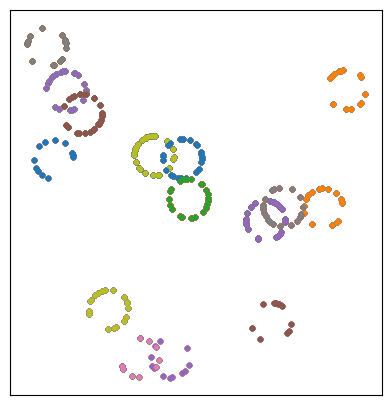

In [4]:
fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(6, 5))
for l in labels:
    axes.plot(data[labels == l, 0], data[labels == l, 1], "o", markersize=3)
axes.set_aspect("equal")
axes.set_xticks([])
axes.set_yticks([])

# Defining the prior
We define a Dirichlet process prior over clusterings with hyperparameter $\alpha=1$.

In [5]:
from smc_clustering.clustering import DirichletProcess


prior = DirichletProcess(alpha=1)

# Defining the surrogate model
For 2D datasets, we use a Normal-inverse-Gamma distribution $N\Gamma^{-1}(\alpha,\beta,\mu,\lambda)$ as a surrogate likelihood to reduce the number of neural likelihood evaluations made.

In [6]:
from smc_clustering.surrogate_models import Gaussian, GaussianCluster

from circles_setup import a, b, lam, mu


surrogate = Gaussian(a, b, mu, lam)

Since the surrogate model is conjugate, cluster likelihoods can be evaluated in constant time with the use of summary statistics. For the Gaussian model, these are the cumulative sums $\sum_i x_i$ and $\sum_i x_i^2$ . We specify a ```ClusterClass``` to allow the required summary statistics to be stored and updated in an online fashion during clustering.

In [7]:
ClusterClass = GaussianCluster

# Running SMC clustering

In [8]:
from smc_clustering.smc import SMCClusterer, plot_particles_2D, resample_greedy

## Hyperparameters
We need to specify the maximum number of particles to be kept after each iteration (```max_particles```), as well as the number of clusterings that are proposed under the surrogate model (```max_evals```). The latter upper bounds the number of likelihood evaluations made at each timestep. We use a greedy resampling scheme.

In [9]:
max_particles = 10
max_evals = 10
resample_fn = resample_greedy

The clustering algorithm is initialised with the required models and hyperparameters. We can optionally specify a ```callback``` function to track progress.

In [10]:
clusterer = SMCClusterer(
    data=data,
    score_fn=batched_likelihood,
    max_particles=max_particles,
    max_evals=max_evals,
    prior=prior,
    surrogate=surrogate,
    resample_fn=resample_fn,
    ClusterClass=ClusterClass,
    callback=plot_particles_2D,
)

Run clustering. The ```cluster``` method returns a log of the number of funtion evaluations and the number of subproblems at each timestep.

 32%|█████▊            | 98/305 [00:23<00:39,  5.25it/s, Subproblems=1, Evals=2]

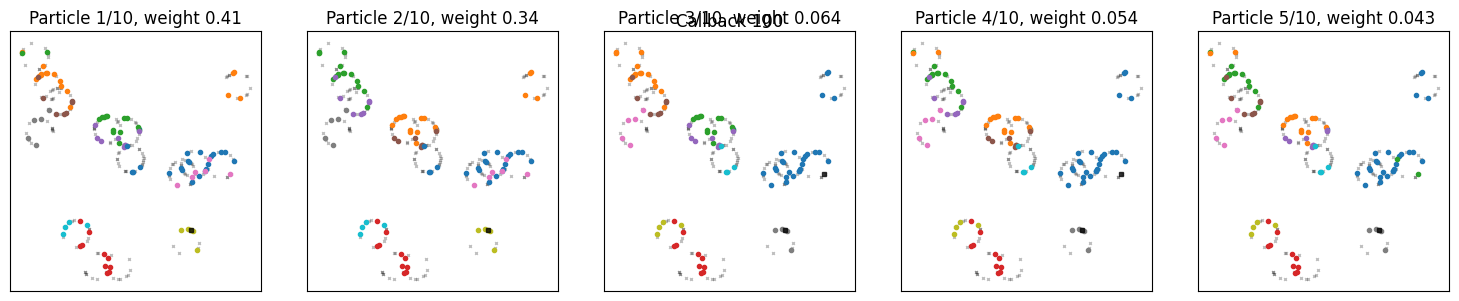

 33%|█████▌           | 100/305 [00:24<00:42,  4.88it/s, Subproblems=1, Evals=6]

1 subproblems of sizes [100]
Subproblem 0: 10 particles, 100 points
	Particle 0, weight 0.41(-6.25), 14 clusters, [18, 13, 13, 10, 8, 7, 6, 5, 5, 4, 4, 4, 2, 1]
	Particle 1, weight 0.34(-6.42), 14 clusters, [18, 14, 13, 10, 7, 7, 6, 5, 5, 4, 4, 4, 2, 1]
	Particle 2, weight 0.064(-8.11), 14 clusters, [23, 13, 13, 10, 8, 7, 5, 5, 4, 4, 4, 2, 1, 1]
	... 7 particles omitted



 65%|██████████▍     | 198/305 [00:50<00:23,  4.52it/s, Subproblems=1, Evals=10]

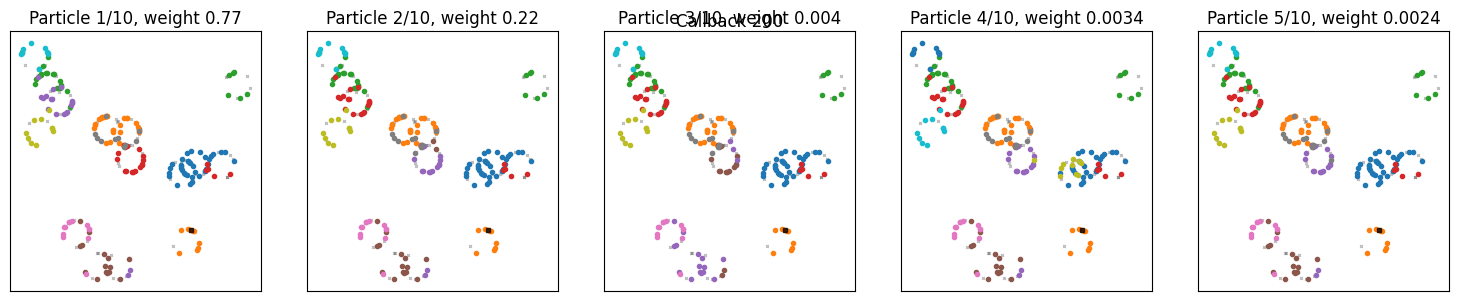

 65%|███████████      | 199/305 [00:50<00:39,  2.69it/s, Subproblems=1, Evals=2]

1 subproblems of sizes [200]
Subproblem 0: 10 particles, 200 points
	Particle 0, weight 0.77(-5.36), 16 clusters, [29, 27, 21, 17, 17, 15, 12, 11, 10, 9, 9, 9, 6, 5, 2, 1]
	Particle 1, weight 0.22(-6.6), 17 clusters, [29, 27, 21, 17, 15, 15, 12, 11, 10, 9, 9, 9, 6, 5, 2, 2, 1]
	Particle 2, weight 0.004(-10.6), 17 clusters, [29, 27, 21, 17, 15, 14, 12, 11, 10, 9, 9, 9, 6, 5, 3, 2, 1]
	... 7 particles omitted



 98%|████████████████▌| 298/305 [01:12<00:01,  3.56it/s, Subproblems=1, Evals=5]

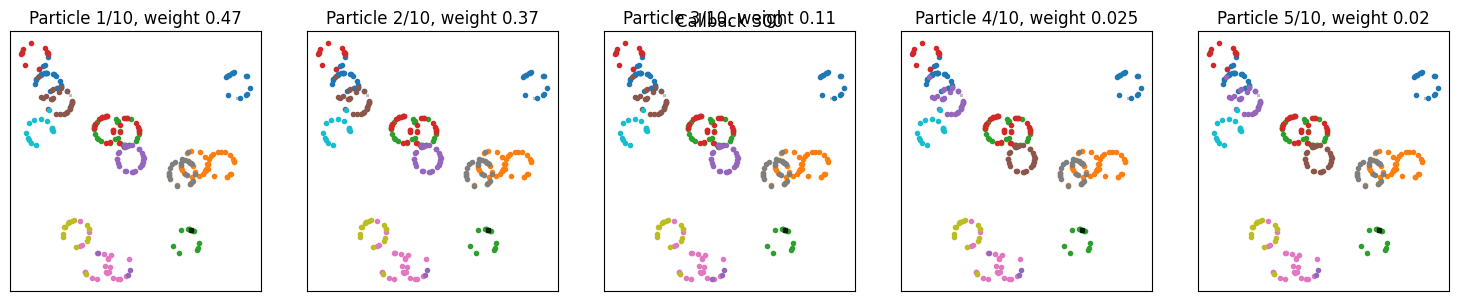

 98%|████████████████▋| 299/305 [01:12<00:02,  2.97it/s, Subproblems=1, Evals=5]

1 subproblems of sizes [300]
Subproblem 0: 10 particles, 300 points
	Particle 0, weight 0.47(-6.98), 16 clusters, [30, 29, 28, 27, 27, 26, 24, 23, 16, 15, 14, 14, 12, 11, 3, 1]
	Particle 1, weight 0.37(-7.21), 16 clusters, [30, 29, 28, 27, 27, 26, 25, 23, 16, 15, 14, 14, 12, 11, 2, 1]
	Particle 2, weight 0.11(-8.43), 16 clusters, [30, 29, 28, 27, 27, 26, 24, 23, 16, 15, 14, 14, 12, 11, 3, 1]
	... 7 particles omitted



100%|█████████████████| 305/305 [01:14<00:00,  4.10it/s, Subproblems=1, Evals=4]

In [11]:
rng = jax.random.PRNGKey(2)
n_evals, n_subprobs = clusterer.cluster(rng, callback_interval=100)

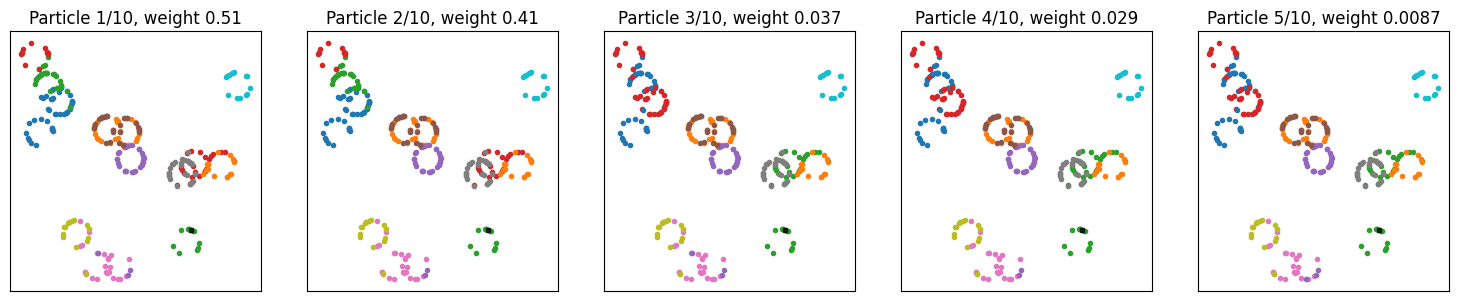

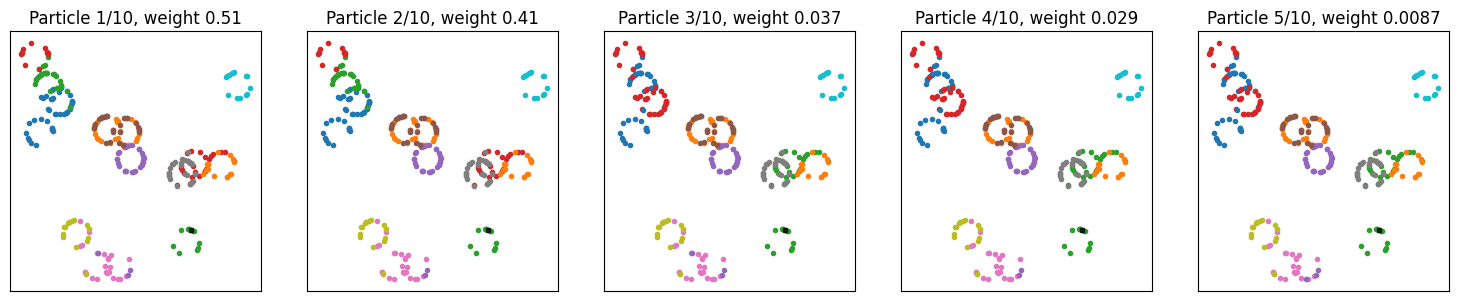

In [12]:
clusterer.callback(clusterer.state)

The cluster labels on the highest-weighted particle can be extracted with the ```list_cluster_labels``` method and used for evaluation.

In [13]:
from smc_clustering.metrics import cluster_metrics


clustering = clusterer.state.list_cluster_labels()
print(cluster_metrics(clustering, ground_truth))

{'precision': 0.6343830827350097, 'recall': 0.6430738538915295, 'f1': 0.6282273847819254}


We can also evaluate the log-posterior density of the highest-weighted clustering in the particle set:

In [14]:
clusterer.best_logpost

Array(-411.47406, dtype=float32)

## Split SMC
We enable clustering with split SMC by setting ```split = True``` in the clusterer setup.

In [15]:
clusterer = SMCClusterer(
    data=data,
    split=True,
    score_fn=batched_likelihood,
    max_particles=max_particles,
    max_evals=max_evals,
    prior=prior,
    surrogate=surrogate,
    resample_fn=resample_fn,
    ClusterClass=ClusterClass,
    callback=plot_particles_2D,
)

 32%|█████▊            | 98/305 [00:20<00:58,  3.55it/s, Subproblems=7, Evals=7]

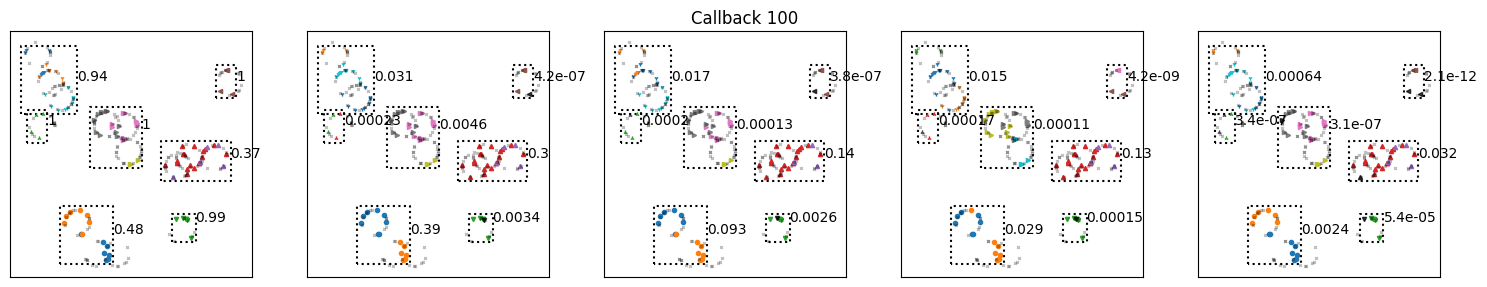

 32%|█████▊            | 99/305 [00:21<01:13,  2.81it/s, Subproblems=7, Evals=7]

7 subproblems of sizes [26, 23, 23, 14, 6, 4, 4]
Subproblem 0: 10 particles, 14 points
	Particle 0, weight 0.48(-2.76), 2 clusters, [7, 7]
	Particle 1, weight 0.39(-2.98), 2 clusters, [8, 6]
	Particle 2, weight 0.093(-4.4), 2 clusters, [7, 7]
	... 7 particles omitted

Subproblem 1: 10 particles, 6 points
	Particle 0, weight 0.99(5.2), 1 clusters, [6]
	Particle 1, weight 0.0034(-0.479), 2 clusters, [5, 1]
	Particle 2, weight 0.0026(-0.751), 2 clusters, [5, 1]
	... 7 particles omitted

Subproblem 2: 8 particles, 23 points
	Particle 0, weight 0.37(-9.33), 2 clusters, [18, 5]
	Particle 1, weight 0.3(-9.53), 2 clusters, [19, 4]
	Particle 2, weight 0.14(-10.3), 2 clusters, [20, 3]
	... 5 particles omitted

Subproblem 3: 5 particles, 4 points
	Particle 0, weight 1(1.39), 1 clusters, [4]
	Particle 1, weight 4.2e-07(-13.3), 2 clusters, [3, 1]
	Particle 2, weight 3.8e-07(-13.4), 2 clusters, [3, 1]
	... 2 particles omitted

Subproblem 4: 9 particles, 26 points
	Particle 0, weight 1(4.77), 3 clust

 65%|██████████▍     | 198/305 [00:54<00:36,  2.91it/s, Subproblems=10, Evals=9]

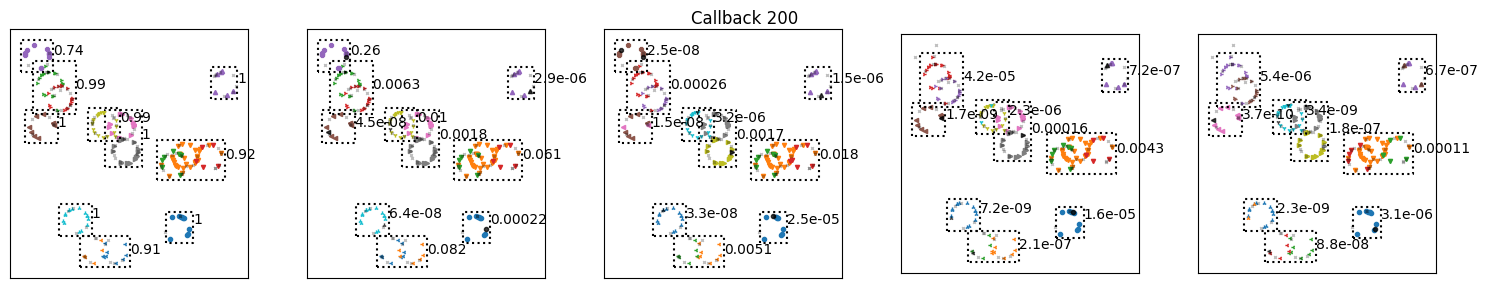

 66%|█████████▊     | 200/305 [00:54<00:35,  2.93it/s, Subproblems=10, Evals=11]

10 subproblems of sizes [42, 36, 35, 21, 15, 14, 12, 10, 9, 6]
Subproblem 0: 10 particles, 10 points
	Particle 0, weight 1(7.22), 1 clusters, [10]
	Particle 1, weight 0.00022(-1.21), 2 clusters, [9, 1]
	Particle 2, weight 2.5e-05(-3.39), 2 clusters, [9, 1]
	... 7 particles omitted

Subproblem 1: 10 particles, 42 points
	Particle 0, weight 0.92(-2.64), 3 clusters, [30, 7, 5]
	Particle 1, weight 0.061(-5.36), 3 clusters, [31, 6, 5]
	Particle 2, weight 0.018(-6.56), 3 clusters, [29, 7, 6]
	... 7 particles omitted

Subproblem 2: 10 particles, 6 points
	Particle 0, weight 1(-0.718), 1 clusters, [6]
	Particle 1, weight 2.9e-06(-13.5), 2 clusters, [5, 1]
	Particle 2, weight 1.5e-06(-14.2), 2 clusters, [5, 1]
	... 7 particles omitted

Subproblem 3: 8 particles, 9 points
	Particle 0, weight 1(9.26), 1 clusters, [9]
	Particle 1, weight 4.5e-08(-7.66), 2 clusters, [8, 1]
	Particle 2, weight 1.5e-08(-8.76), 2 clusters, [7, 2]
	... 5 particles omitted

Subproblem 4: 6 particles, 35 points
	Particle

 98%|████████████████▌| 298/305 [01:26<00:02,  3.16it/s, Subproblems=8, Evals=9]

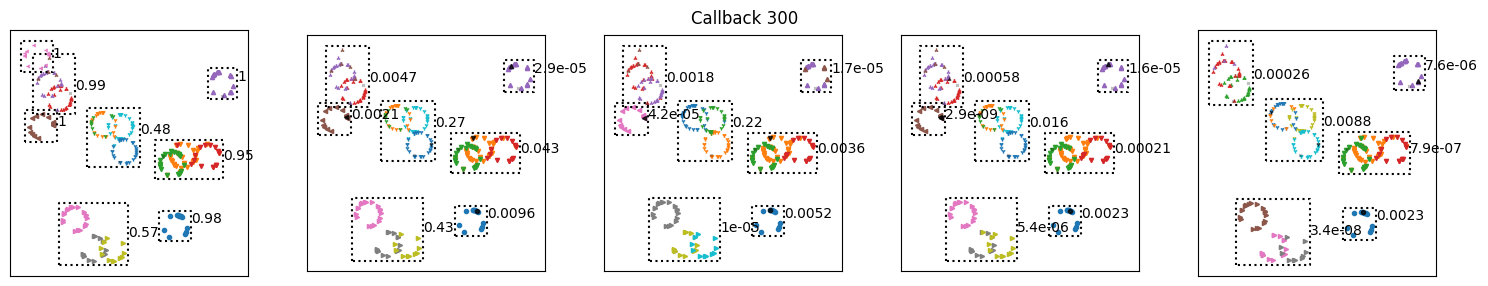

 98%|████████████████▋| 299/305 [01:26<00:02,  2.72it/s, Subproblems=8, Evals=9]

8 subproblems of sizes [83, 65, 54, 43, 14, 14, 14, 13]
Subproblem 0: 10 particles, 13 points
	Particle 0, weight 0.98(3.37), 1 clusters, [13]
	Particle 1, weight 0.0096(-1.26), 2 clusters, [12, 1]
	Particle 2, weight 0.0052(-1.87), 2 clusters, [12, 1]
	... 7 particles omitted

Subproblem 1: 10 particles, 65 points
	Particle 0, weight 0.95(9.2), 3 clusters, [30, 20, 15]
	Particle 1, weight 0.043(6.1), 4 clusters, [30, 20, 14, 1]
	Particle 2, weight 0.0036(3.63), 4 clusters, [32, 18, 14, 1]
	... 7 particles omitted

Subproblem 2: 10 particles, 14 points
	Particle 0, weight 1(-0.619), 1 clusters, [14]
	Particle 1, weight 2.9e-05(-11.1), 2 clusters, [13, 1]
	Particle 2, weight 1.7e-05(-11.6), 2 clusters, [10, 4]
	... 7 particles omitted

Subproblem 3: 4 particles, 14 points
	Particle 0, weight 1(-1.17), 1 clusters, [14]
	Particle 1, weight 0.0021(-7.31), 2 clusters, [13, 1]
	Particle 2, weight 4.2e-05(-11.2), 2 clusters, [13, 1]
	... 1 particles omitted

Subproblem 4: 10 particles, 43 poi

100%|███████████████| 305/305 [01:28<00:00,  3.44it/s, Subproblems=10, Evals=10]

In [16]:
rng = jax.random.PRNGKey(2)
n_evals, n_subprobs = clusterer.cluster(rng, callback_interval=100)

Subproblems are indicated with dotted bounding boxes around their datapoints, annotated with the weight of the plotted particle in that subproblem.

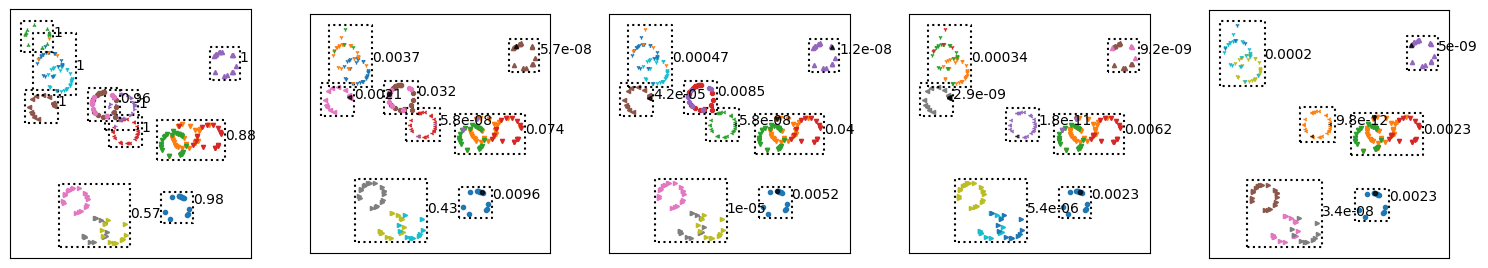

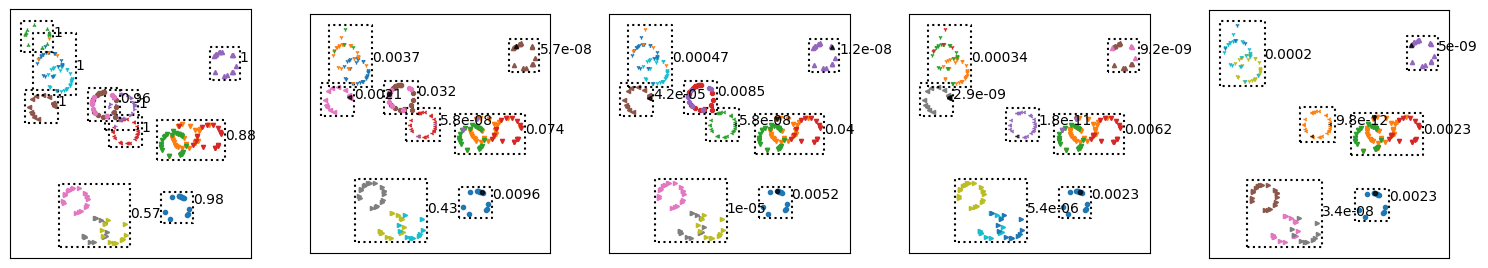

In [17]:
clusterer.callback(clusterer.state)

In [18]:
clustering = clusterer.list_cluster_labels()
print(cluster_metrics(clustering, ground_truth))

{'precision': 0.828036562075425, 'recall': 0.7737644042157228, 'f1': 0.7901382102752226}


In [19]:
clusterer.best_logpost

Array(-37.286682, dtype=float32)

# Running MCMC clustering

In [20]:
from smc_clustering.agglomerative import plot_callback
from smc_clustering.mcmc import GibbsClusterer

The MCMC clustering uses the same ingredients as SMC. The use of a surrogate is optional - if one is specified then Metropolis-within-Gibbs is used with the surrogate as the proposal distribtion.

In [21]:
clusterer = GibbsClusterer(
    data=data,
    score_fn=batched_likelihood,
    prior=prior,
    surrogate=surrogate,
    ClusterClass=GaussianCluster,
)

In [22]:
rng = jax.random.PRNGKey(2)
n_evals = clusterer.cluster(rng, sweeps=10)

100%|█| 10/10 [05:46<00:00, 34.66s/it, Sweep progress=306/306, Best=-333.9, Curr

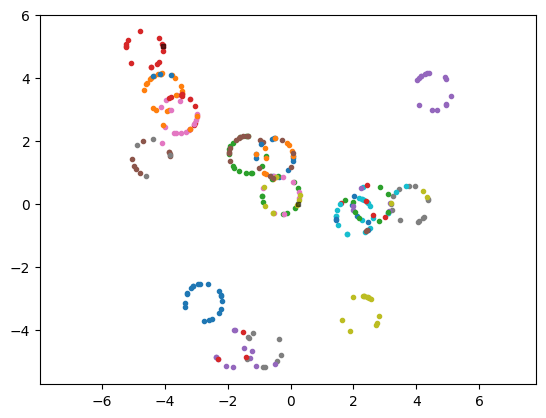

In [23]:
plot_callback(clusterer)

The current list of clusters can be found in the```clusters``` attribute, and its log-posterior density in ```logpost```. We also record the best clustering found so far in ```best_clustering``` and ```best_logpost```. A list of cluster labels for each datapoint under this clustering can be generated with the ```list_cluster_labels``` method.

In [24]:
clustering = clusterer.list_cluster_labels()
print(cluster_metrics(clustering, ground_truth))

{'precision': 0.859366849562928, 'recall': 0.48600425599242364, 'f1': 0.5820088937534642}


In [25]:
clusterer.best_logpost

Array(-333.8795, dtype=float32)

# Running agglomerative clustering

In [26]:
from smc_clustering.agglomerative import Clusterer

The optional ```cluster_batch_size``` argument controls the number of merges evaluted at each iteration -- by default, every possible pairwise merge is considered, otherwise a subset of ```cluster_batch_size``` clusters are sampled and all pairwise merges between clusters in this subset are evaluated. 

In [27]:
clusterer = Clusterer(data=data, score_fn=batched_likelihood, prior=prior, cluster_batch_size=16)

Run clustering for ```max_iter``` iterations -- the algorithm will terminate early if every possible candidate merge has been rejected, in which case ```done``` will return as ```True```.

In [28]:
n_evals, done = clusterer.cluster(rng, max_iter=500)

100%|██████| 500/500 [08:05<00:00,  1.03it/s, Best score=3.73, Objective=-307.1]


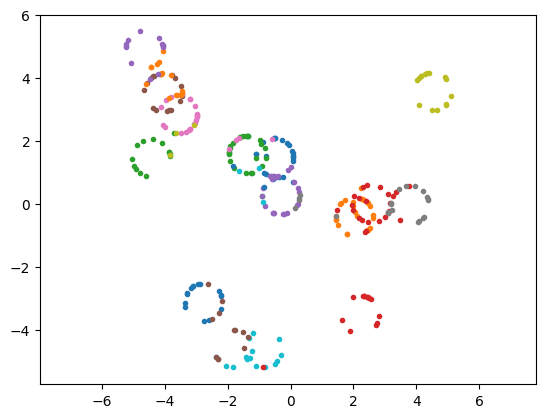

In [29]:
plot_callback(clusterer)

A list of cluster labels for each datapoint can be generated with the ```list_cluster_labels``` method. The current list of clusters can be found in the```clusters``` attribute, and its log-posterior density in ```objective```.

In [30]:
clustering = clusterer.list_cluster_labels()
print(cluster_metrics(clustering, ground_truth))

{'precision': 0.6860904164825733, 'recall': 0.5850612482115809, 'f1': 0.6187897464456508}


In [31]:
clusterer.objective

Array(-307.08322, dtype=float32)